In [2]:
from huggingface_hub import notebook_login
notebook_login()

In [1]:
from huggingface_hub import hf_hub_download
import os

# Descargar el checkpoint oficial de SAM 3
#checkpoint_path = hf_hub_download(
#    repo_id="facebook/sam3", 
#    filename="sam3.pt"
#)

checkpoint_path = os.path.abspath("sam3.pt")
print("Checkpoint de SAM 3 descargado con éxito en:", checkpoint_path)

Checkpoint de SAM 3 descargado con éxito en: c:\Users\dksfd\roboFut\sam3.pt


Resolución del video: 540x480 píxeles


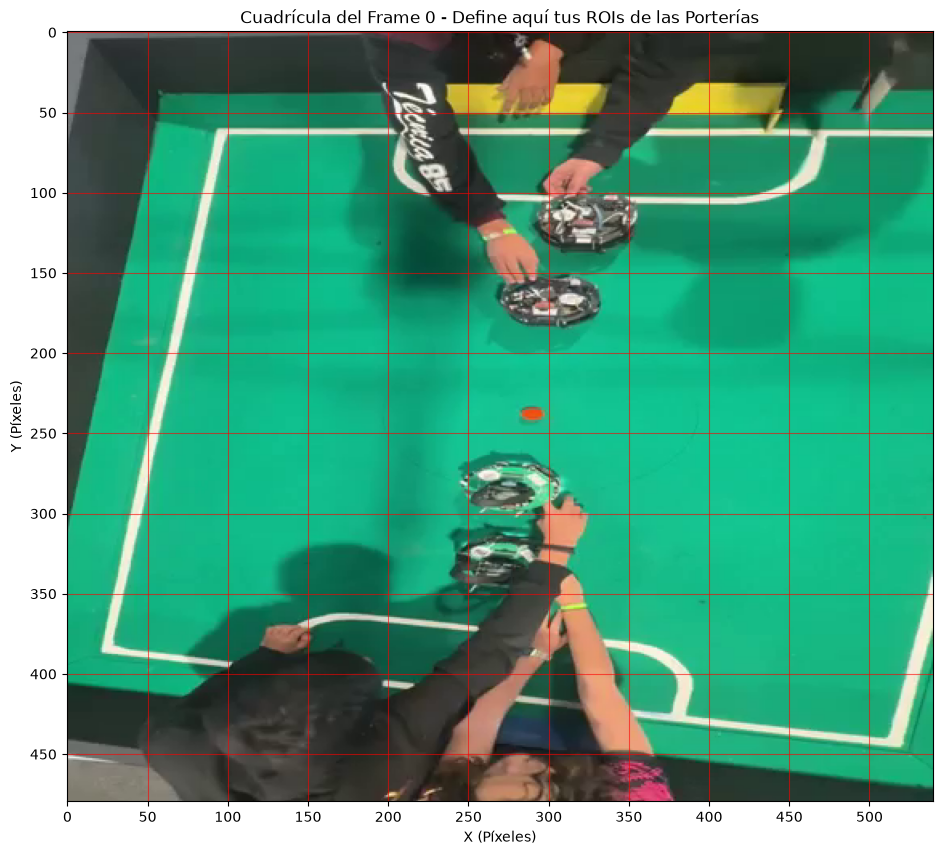

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

video_path = "robot_video.mp4"

# (Frame 0)
cap = cv2.VideoCapture(video_path)
ret, frame0 = cap.read()
cap.release()

if ret:
    frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
    h, w, _ = frame0.shape
    print(f"Resolución del video: {w}x{h} píxeles")
    
    # Graficar con cuadrícula visible y marcas cada 50 píxeles
    plt.figure(figsize=(12, 10))
    plt.imshow(frame0_rgb)
    plt.grid(True, color='red', alpha=0.6, linestyle='-')
    
    plt.xticks(np.arange(0, w, 50))
    plt.yticks(np.arange(0, h, 50))
    
    plt.title("Cuadrícula del Frame 0 - Define aquí tus ROIs de las Porterías")
    plt.xlabel("X (Píxeles)")
    plt.ylabel("Y (Píxeles)")
    plt.show()
else:
    print("Error: No se pudo abrir el video. Asegúrate de que 'robot_video.mp4' esté en la misma carpeta.")

In [ ]:
from ultralytics.models.sam import SAM3VideoSemanticPredictor
import torch
import cv2
import numpy as np
import supervision as sv
import sys
import importlib

if 'soccer_tracker' in sys.modules:
    importlib.reload(sys.modules['soccer_tracker'])

import soccer_tracker
importlib.reload(soccer_tracker)
from soccer_tracker import SoccerTracker    

video_path = "robot_video.mp4" 
output_video_path = "cancha_robot_tracking_sam3.mp4"

# None = video completo.
max_frames = 100

# 10 = debug,
# None = frames originales.
target_fps = 10

# ROIs de porterías
# [x1, y1, x2, y2, x3, y3, x4, y4]
# Orden: arriba-izquierda, arriba-derecha, abajo-derecha, abajo-izquierda.
# Frame 0
yellow_goal_roi = [210, 25, 440, 25, 440, 60, 210, 60]       # Portería superior (Amarilla)
blue_goal_roi = [150, 400, 340, 425, 330, 450, 130, 425]     # Portería inferior (Azul)

# cm por píxel
cm_per_pixel = 0.364 
 
possession_threshold = 45.0 

cap = cv2.VideoCapture(video_path)
orig_fps = cap.get(cv2.CAP_PROP_FPS)
if not orig_fps or orig_fps == 0:
    orig_fps = 30.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

if target_fps is not None and target_fps < orig_fps:
    vid_stride = max(1, int(round(orig_fps / target_fps)))
    effective_fps = orig_fps / vid_stride
else:
    vid_stride = 1
    effective_fps = orig_fps

print(f"FPS Original: {orig_fps:.2f} | Vid Stride (Salto): {vid_stride} | FPS Efectivo: {effective_fps:.2f}")

# centros verticales de porterías para asignación de equipos
yellow_center_y = float(np.mean(yellow_goal_roi[1::2]))
blue_center_y = float(np.mean(blue_goal_roi[1::2]))

# SAM 3
overrides = dict(
    conf=0.40, 
    task="segment", 
    mode="predict", 
    model=checkpoint_path,
    vid_stride=vid_stride
)
if torch.cuda.is_available():
    overrides["half"] = True

video_predictor = SAM3VideoSemanticPredictor(overrides=overrides)

# predicción en streaming
resultados_video = video_predictor(
    source=video_path,
    text=["red ball", "robot"],
    stream=True
)

writer = cv2.VideoWriter(
    output_video_path,
    cv2.VideoWriter_fourcc(*"mp4v"), effective_fps, (w, h)
)

soccer_tracker = SoccerTracker(
    fps=effective_fps,
    cm_per_pixel=cm_per_pixel,
    possession_threshold=possession_threshold,
    yellow_goal_roi=yellow_goal_roi,
    blue_goal_roi=blue_goal_roi,
    team_mapping={}, # Se llena dinámicamente según la detección y tracking
    debug = True
)

print("Procesando video SAM 3 (Texto)...")
for idx, res in enumerate(resultados_video):
    # Control del límite de frames para pruebas rápidas
    if max_frames is not None and idx >= max_frames:
        print(f"({max_frames}) | max frames Finalizando...")
        break
        
    frame = res.orig_img
    det = sv.Detections.from_ultralytics(res)
    
    ball_box = None
    ball_candidates = []
    robot_boxes_dict = {}
    masks_dict = {}
    
    def box_area(box):
        return float(box[2] * box[3])

    def ball_inside_robot(candidate_box):
        bx, by, bw, bh = candidate_box
        ball_cx = bx + bw / 2.0
        ball_cy = by + bh / 2.0
        for robot_box in robot_boxes_dict.values():
            rx, ry, rw, rh = robot_box
            margin_x = rw * 0.12
            margin_y = rh * 0.12
            if (rx - margin_x) <= ball_cx <= (rx + rw + margin_x) and (ry - margin_y) <= ball_cy <= (ry + rh + margin_y):
                return True
        return False
    
    if len(det) > 0:
        for i in range(len(det)):
            # bounding boxes de [xmin, ymin, xmax, ymax] a [x, y, w, h]
            xmin, ymin, xmax, ymax = det.xyxy[i]
            box = [float(xmin), float(ymin), float(xmax - xmin), float(ymax - ymin)]
            
            cls_id = int(det.class_id[i])
            track_id = int(det.tracker_id[i]) if det.tracker_id is not None else i
            conf = float(det.confidence[i]) if getattr(det, "confidence", None) is not None else 1.0
            
            # class_id 0 = "red ball", class_id 1 = "robot"
            if cls_id == 0:
                area = box_area(box)
                aspect_ratio = box[2] / max(1e-6, box[3])
                if conf >= 0.50 and 80 <= area <= 1200 and 0.45 <= aspect_ratio <= 2.25:
                    ball_candidates.append((conf, box))
            elif cls_id == 1:
                box_area_robot = (xmax - xmin) * (ymax - ymin)

                if box_area_robot > 1500 and box_area_robot < 5300:  # Ajusta estos valores
                    robot_boxes_dict[track_id] = box
                    masks_dict[track_id] = det.mask[i] if det.mask is not None else None
                
                    # Mapear el equipo, primera vez
                    if track_id not in soccer_tracker.team_mapping:
                        # Centro
                        ry = ymin + (ymax - ymin) / 2.0
                        
                        # distancias a las porterías
                        dist_to_yellow = abs(ry - yellow_center_y)
                        dist_to_blue = abs(ry - blue_center_y)
                        
                        # Asignar equipo por la porteria mas cercana
                        if dist_to_yellow < dist_to_blue:
                            team_name = "Robot Yellow"
                        else:
                            team_name = "Robot Blue"
                            
                        soccer_tracker.team_mapping[track_id] = f"{team_name} {track_id}"
                    
    if ball_candidates:
        # quitar las cajas que caen dentro de robots.
        valid_candidates = [item for item in ball_candidates if not ball_inside_robot(item[1])]

        # ordenar por confianza y quedarnos con la mejor.
        if valid_candidates:
            valid_candidates.sort(key=lambda item: item[0], reverse=True)
            ball_box = [box for _, box in valid_candidates]
        else:
            # mantener una sola candidata razonable.
            ball_candidates.sort(key=lambda item: item[0], reverse=True)
            ball_box = ball_candidates[0][1]
    
    # Actualizar
    soccer_tracker.update(idx, ball_box, robot_boxes_dict)
    annotated = soccer_tracker.annotate_frame(frame, ball_box, robot_boxes_dict, masks_dict)
    writer.write(annotated)

writer.release()
print(f"Video guardado: {output_video_path}")

FPS Original: 30.00 | Vid Stride (Salto): 3 | FPS Efectivo: 10.00
Procesando video SAM 3 (Texto)...

Ultralytics 8.4.66  Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]
video 1/1 (frame 1/1367) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 769.0ms
video 1/1 (frame 2/1367) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 432.1ms
video 1/1 (frame 3/1367) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 368.4ms
video 1/1 (frame 4/1367) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 384.0ms
video 1/1 (frame 5/1367) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 433.6ms
video 1/1 (frame 6/1367) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 422.8ms
video 1/1 (frame 7/1367) c:\Users\dksfd\roboFut\robot_video.mp4: 644x644 1 red ball, 5 robots, 462.1m


             ESTADÍSTICAS DEL PARTIDO          
Marcador Final:
  Equipo Amarillo: 0 goles
  Equipo Azul: 0 goles

Historial y Minuto de Goles:

Tiempo de Posesión de Balón:
  - Team Yellow: 0.40 segundos (4.0%)
  - Team Blue: 0.70 segundos (7.0%)
  - Loose: 8.90 segundos (89.0%)

Rendimiento de Velocidad de los Robots:
  - Robot Yellow 1 (ID 1):
    * Velocidad Promedio: 22.72 cm/s
    * Velocidad Máxima: 95.66 cm/s
  - Robot Blue 3 (ID 3):
    * Velocidad Promedio: 10.60 cm/s
    * Velocidad Máxima: 46.19 cm/s
  - Robot Blue 4 (ID 4):
    * Velocidad Promedio: 8.54 cm/s
    * Velocidad Máxima: 42.61 cm/s
  - Robot Yellow 2 (ID 2):
    * Velocidad Promedio: 11.76 cm/s
    * Velocidad Máxima: 51.12 cm/s



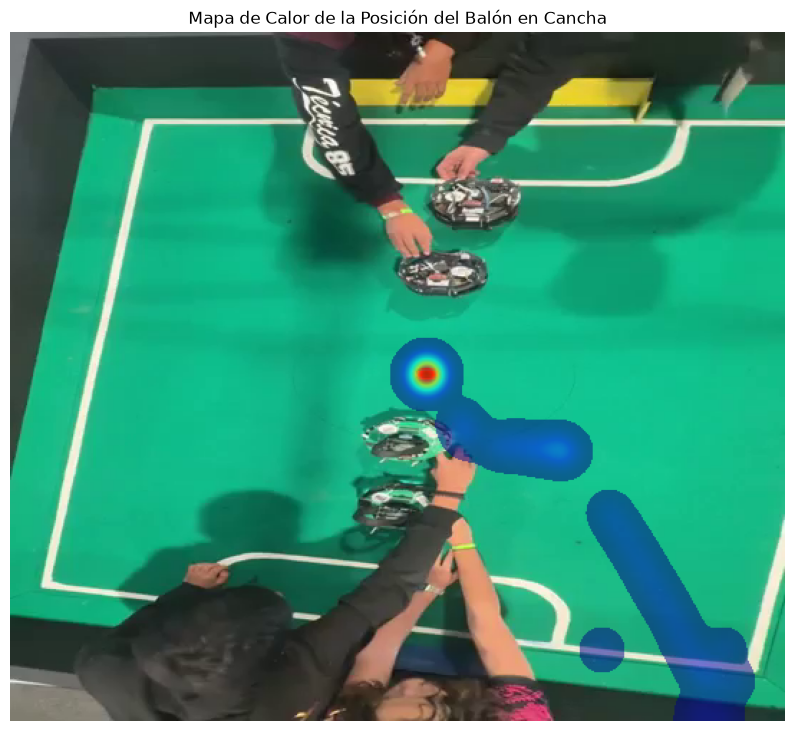

In [ ]:
import matplotlib.pyplot as plt

stats = soccer_tracker.get_statistics()

print("\n==============================================")
print("             ESTADÍSTICAS DEL PARTIDO          ")
print("==============================================")
print(f"Marcador Final:")
print(f"  Equipo Amarillo: {stats['final_score']['Team Yellow']} goles")
print(f"  Equipo Azul: {stats['final_score']['Team Blue']} goles")

print("\nHistorial y Minuto de Goles:")
for i, g in enumerate(stats['goals'], 1):
    print(f"  {i}. Gol de {g['team']} en el segundo {g['time']:.2f} (Frame {g['frame']})")

print("\nTiempo de Posesión de Balón:")
for team, sec in stats['possession_seconds'].items():
    pct = stats['possession_percentage'][team]
    print(f"  - {team}: {sec:.2f} segundos ({pct:.1f}%)")

print("\nRendimiento de Velocidad de los Robots:")
for obj_id, data in stats['robot_speeds'].items():
    print(f"  - {data['team']} (ID {obj_id}):")
    print(f"    * Velocidad Promedio: {data['avg_speed']:.2f} cm/s")
    print(f"    * Velocidad Máxima: {data['max_speed']:.2f} cm/s")
print("==============================================\n")

# Mapa de Calor 
cap = cv2.VideoCapture(video_path)
ret, frame0 = cap.read()
cap.release()

if ret:
    heatmap_cancha = soccer_tracker.generate_heatmap(frame0, kernel_size=51, alpha=0.5)
    cv2.imwrite("heatmap_pelota.png", heatmap_cancha)

    plt.figure(figsize=(10, 12))
    plt.imshow(cv2.cvtColor(heatmap_cancha, cv2.COLOR_BGR2RGB))
    plt.title("Mapa de Calor de la Posición del Balón en Cancha")
    plt.axis('off')
    plt.show()
else:
    print("Sin frame0")